# ECB Web Scraping Project
**Author:** Natalia Namyslowska  
---

## 1. Introduction

The goal of this project is to scrape the European Central Bank (ECB) website and analyse how their communication about artificial intelligence, digital finance, and monetary policy has changed over the years 2019 to 2026.

I chose the ECB because my bachelor thesis was about sentiment analysis on Financial Times headlines, and I wanted to extend that idea to look at how a major institution like the ECB talks about topics like AI and digital currencies. 

I scraped two types of ECB documents:
- **Speeches** — talks given by ECB board members at conferences, universities, etc.
- **Press releases** — official announcements about policy decisions, appointments, etc.

The project uses all four required libraries:
- `requests` and `BeautifulSoup` — for downloading and parsing data
- `Selenium` — for extracting full speech text (browser automation)
- `Scrapy` — for extracting full press release text (crawling framework)
- `re` (regex) — for finding keyword mentions in the text

## 2. Why the ECB Website is Legal to Scrape

Before starting the project I checked whether it is legal to scrape the ECB website. Here is what I found:

1. **EU Open Data Directive (2019/1024/EU)** — EU institutions are required to make their data reusable by the public. The ECB is an EU institution.

2. **ECB robots.txt** — I checked `https://www.ecb.europa.eu/robots.txt` and it does not have a general ban on scraping. It only blocks a few internal paths (like video files). It does specify `Crawl-delay: 5` which means we should wait 5 seconds between requests, and I respected that in all my scripts.

3. **ECB RSS feeds** — The ECB provides RSS feeds at `https://www.ecb.europa.eu/home/html/rss.en.html` which are designed for machines to read. If they provide machine-readable feeds, they clearly expect automated access.

4. **Non-commercial academic use** — This is a university project, not a commercial product. I am not selling the data or using it for profit.

5. **No personal data** — I am only scraping public speeches and press releases. No user data.

All of this is documented in the `legal_proof.txt` file included in the submission.

## 3. How I Discovered the ECB Data Source

### First attempt: RSS feeds

My first idea was to use the ECB's RSS feeds because they are plain XML and `requests` can download them easily. The problem is that each RSS feed only returns the **15 most recent** items. That gives me about 75 articles total across 5 feeds, which is way too little for a proper analysis of 2019-2026.

### Second attempt: archive pages

I tried to access year-based archive pages like `/press/key/date/2024/html/index.en.html` but those returned 404 errors. The ECB restructured their website at some point and the old URL pattern does not work anymore.

I did find that the `index_include.en.html` pages work (these are HTML fragments that the website's JavaScript loads), but they only cover certain content types and some years are missing.

### Final solution: the JSON dataset

By inspecting the network requests in the browser (using Chrome DevTools, Network tab), I discovered that the ECB's "All news & publications" page loads its data from a JSON API. The URL looks like this:

```
https://www.ecb.europa.eu/foedb/dbs/foedb/publications.en/.../metadata.json
```

This JSON dataset contains **all** ECB publications — thousands of records with metadata like title, date, type, and links. The data is split into chunks that can be downloaded with simple `requests.get()` calls.

There is also a separate `publications_types` dataset that maps type IDs to names. I wrote a small script (`discover_types.py`) to find that:
- **Type 1** = ECB Press release
- **Type 19** = ECB Speech


## 4. Project Structure

Here is how the project is organised:

| File | What it does | Libraries used |
|------|-------------|----------------|
| `01_speech_json_requests.py` | Collects speech metadata from ECB JSON | `requests` |
| `01b_press_json_requests.py` | Collects press release metadata from ECB JSON | `requests` |
| `02_selenium.py` | Extracts full speech text from HTML pages | `Selenium`, `BeautifulSoup` |
| `ecb_scrapy/` (Scrapy project) | Extracts full press release text | `Scrapy` |
| `04_analysis.ipynb` | Regex analysis and final dataframe | `re`, `pandas`, `matplotlib` |

I decided to use **Selenium for speeches** and **Scrapy for press releases** so that each tool handles a different content type.

### Why not just use one tool for everything?

I could have used just Selenium or just Scrapy for all the full-text extraction, but the course requires demonstrating all four libraries. By splitting the work between Selenium and Scrapy, each tool gets a real usage.

## 5. Step 1 — Collecting Article Metadata with `requests`

The first step is to download the ECB's JSON dataset and extract metadata for speeches and press releases. This is done in two separate scripts but the logic is the same.

### How the JSON dataset works

1. First we download `metadata.json` which tells us how many records exist, what the fields are called, and how big each chunk is.
2. Then we download the data chunks (big JSON arrays with all the records).
3. We rebuild the rows by mapping each value to its field name using the header.
4. We filter by type (19 for speeches, 1 for press releases) and year (2019-2026).
5. We save to CSV.

### 5.1 Collecting Speeches (type = 19)

In [1]:
# ============================================================
# STEP 1A: COLLECT SPEECH METADATA FROM ECB JSON DATASET
#
# This downloads the ECB's internal JSON publication database,
# filters for speeches (type = 19) from 2019-2026,
# and saves the results to CSV.
#
# The JSON dataset was discovered by inspecting network
# requests on the ECB website using Chrome DevTools.
# ============================================================

import requests
import csv
import os
import math
from datetime import datetime, UTC
from collections import Counter

# --- CONFIGURATION ---

BASE_DATASET = "https://www.ecb.europa.eu/foedb/dbs/foedb/publications.en/1775134838/wr3YWp5G"
METADATA_URL = BASE_DATASET + "/metadata.json"

OUTPUT_FILE = "data/ecb_speeches_json.csv"

SPEECH_TYPE_ID = 19   # found via discover_types.py
START_YEAR = 2019
END_YEAR = 2026

os.makedirs("data", exist_ok=True)

# --- HELPER FUNCTIONS ---

def unix_to_date_string(timestamp_value):
    """Converts Unix timestamp to YYYY-MM-DD."""
    if timestamp_value is None:
        return ""
    try:
        timestamp_value = int(timestamp_value)
        return datetime.fromtimestamp(timestamp_value, UTC).strftime("%Y-%m-%d")
    except Exception:
        return ""


def get_best_link(document_types):
    """Returns the best link: English HTML > English PDF > any PDF."""
    if not document_types:
        return ""
    for item in document_types:
        if isinstance(item, str) and item.endswith(".en.html"):
            return ("https://www.ecb.europa.eu" + item) if item.startswith("/") else item
    for item in document_types:
        if isinstance(item, str) and item.endswith(".en.pdf"):
            return ("https://www.ecb.europa.eu" + item) if item.startswith("/") else item
    for item in document_types:
        if isinstance(item, str) and item.endswith(".pdf"):
            return ("https://www.ecb.europa.eu" + item) if item.startswith("/") else item
    return ""


def get_title(properties):
    """Extract title from publicationProperties."""
    if not isinstance(properties, dict):
        return ""
    value = properties.get("Title", "")
    if isinstance(value, list):
        return value[0] if value else ""
    return value


def get_subtitle(properties):
    """Extract subtitle from publicationProperties."""
    if not isinstance(properties, dict):
        return ""
    value = properties.get("Subtitle", "")
    if isinstance(value, list):
        return value[0] if value else ""
    return value


def get_link_type(link):
    if link.endswith(".html"):
        return "html"
    elif link.endswith(".pdf"):
        return "pdf"
    return ""


# --- DOWNLOAD METADATA ---

print("Downloading metadata...")
meta_response = requests.get(METADATA_URL, timeout=30)
metadata = meta_response.json()

header = metadata["header"]
total_records = metadata["total_records"]
chunk_size = metadata["chunk_size"]
num_chunks = math.ceil(total_records / chunk_size)

print(f"Total records in dataset: {total_records}")
print(f"Chunks to download: {num_chunks}")

# --- DOWNLOAD ALL CHUNKS ---

all_rows = []

for chunk_number in range(num_chunks):
    chunk_url = f"{BASE_DATASET}/data/0/chunk_{chunk_number}.json"
    response = requests.get(chunk_url, timeout=60)

    if response.status_code != 200:
        continue

    chunk_data = response.json()
    field_count = len(header)

    if len(chunk_data) % field_count != 0:
        continue

    rows_in_chunk = len(chunk_data) // field_count
    print(f"  Chunk {chunk_number + 1}/{num_chunks}: {rows_in_chunk} rows")

    for row_num in range(rows_in_chunk):
        start = row_num * field_count
        row_values = chunk_data[start:start + field_count]
        row_dict = dict(zip(header, row_values))
        all_rows.append(row_dict)

print(f"\nTotal rows: {len(all_rows)}")

# --- FILTER SPEECHES ---

speech_rows = []

for row in all_rows:
    if row.get("type") != SPEECH_TYPE_ID:
        continue
    row_year = row.get("year")
    if row_year is None:
        continue
    try:
        row_year = int(row_year)
    except Exception:
        continue
    if row_year < START_YEAR or row_year > END_YEAR:
        continue

    properties = row.get("publicationProperties", {})
    document_types = row.get("documentTypes", [])

    link = get_best_link(document_types)

    speech_rows.append({
        "doc_type": "speech",
        "title": get_title(properties),
        "subtitle": get_subtitle(properties),
        "date": unix_to_date_string(row.get("pub_timestamp")),
        "year": row_year,
        "author": row.get("Authors", ""),
        "boardmember": row.get("boardmember", ""),
        "link": link,
        "link_type": get_link_type(link),
        "source": "json_dataset"
    })

# --- DEDUPLICATE ---

unique_speeches = []
seen = set()
for row in speech_rows:
    if row["link"] and row["link"] not in seen:
        seen.add(row["link"])
        unique_speeches.append(row)

unique_speeches.sort(key=lambda x: (x["year"], x["date"]))

# --- SAVE ---

with open(OUTPUT_FILE, "w", newline="", encoding="utf-8") as f:
    fieldnames = ["doc_type", "title", "subtitle", "date", "year",
                  "author", "boardmember", "link", "link_type", "source"]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(unique_speeches)

print(f"\nSaved {len(unique_speeches)} speeches to {OUTPUT_FILE}")

year_counts = Counter(r["year"] for r in unique_speeches)
for year in sorted(year_counts):
    print(f"  {year}: {year_counts[year]}")

Total records in dataset: 19667
Chunks to download: 79
  Chunk 1/79: 250 rows
  Chunk 2/79: 250 rows
  Chunk 3/79: 250 rows
  Chunk 4/79: 250 rows
  Chunk 5/79: 250 rows
  Chunk 6/79: 250 rows
  Chunk 7/79: 250 rows
  Chunk 8/79: 250 rows
  Chunk 9/79: 250 rows
  Chunk 10/79: 250 rows
  Chunk 11/79: 250 rows
  Chunk 12/79: 250 rows
  Chunk 13/79: 250 rows
  Chunk 14/79: 250 rows
  Chunk 15/79: 250 rows
  Chunk 16/79: 250 rows
  Chunk 17/79: 250 rows
  Chunk 18/79: 250 rows
  Chunk 19/79: 250 rows
  Chunk 20/79: 250 rows
  Chunk 21/79: 250 rows
  Chunk 22/79: 250 rows
  Chunk 23/79: 250 rows
  Chunk 24/79: 250 rows
  Chunk 25/79: 250 rows
  Chunk 26/79: 250 rows
  Chunk 27/79: 250 rows
  Chunk 28/79: 250 rows
  Chunk 29/79: 250 rows
  Chunk 30/79: 250 rows
  Chunk 31/79: 250 rows
  Chunk 32/79: 250 rows
  Chunk 33/79: 250 rows
  Chunk 34/79: 250 rows
  Chunk 35/79: 250 rows
  Chunk 36/79: 250 rows
  Chunk 37/79: 250 rows
  Chunk 38/79: 250 rows
  Chunk 39/79: 250 rows
  Chunk 40/79: 250

### 5.2 Collecting Press Releases (type = 1)

The same approach as for speeches, but now we filter for `type = 1` (ECB Press release). The code is almost identical — I just changed the type ID and the output file name.

In [2]:
# ============================================================
# STEP 1B: COLLECT PRESS RELEASE METADATA
#
# Same approach as speeches but filtering for type = 1.
# ============================================================

OUTPUT_FILE_PRESS = "data/ecb_press_releases_json.csv"
PRESS_RELEASE_TYPE_ID = 1

# We already have all_rows from the speech step above,
# so we can just filter again without re-downloading.

# But if all_rows is not available (e.g. running cells out of order),
# we need to re-download.
try:
    _ = all_rows[0]
    print(f"Using existing data ({len(all_rows)} rows already in memory)")
except NameError:
    print("Re-downloading data chunks...")
    meta_response = requests.get(METADATA_URL, timeout=30)
    metadata = meta_response.json()
    header = metadata["header"]
    num_chunks = math.ceil(metadata["total_records"] / metadata["chunk_size"])
    all_rows = []
    for cn in range(num_chunks):
        resp = requests.get(f"{BASE_DATASET}/data/0/chunk_{cn}.json", timeout=60)
        if resp.status_code != 200:
            continue
        cd = resp.json()
        fc = len(header)
        for rn in range(len(cd) // fc):
            s = rn * fc
            all_rows.append(dict(zip(header, cd[s:s+fc])))
    print(f"Downloaded {len(all_rows)} rows")

# Filter for press releases
press_rows = []

for row in all_rows:
    if row.get("type") != PRESS_RELEASE_TYPE_ID:
        continue
    row_year = row.get("year")
    if row_year is None:
        continue
    try:
        row_year = int(row_year)
    except Exception:
        continue
    if row_year < START_YEAR or row_year > END_YEAR:
        continue

    properties = row.get("publicationProperties", {})
    document_types = row.get("documentTypes", [])
    link = get_best_link(document_types)

    press_rows.append({
        "doc_type": "press_release",
        "title": get_title(properties),
        "subtitle": get_subtitle(properties),
        "date": unix_to_date_string(row.get("pub_timestamp")),
        "year": row_year,
        "link": link,
        "link_type": get_link_type(link),
        "source": "json_dataset"
    })

# Deduplicate
unique_press = []
seen_p = set()
for row in press_rows:
    if row["link"] and row["link"] not in seen_p:
        seen_p.add(row["link"])
        unique_press.append(row)

unique_press.sort(key=lambda x: (x["year"], x["date"]))

with open(OUTPUT_FILE_PRESS, "w", newline="", encoding="utf-8") as f:
    fieldnames = ["doc_type", "title", "subtitle", "date", "year",
                  "link", "link_type", "source"]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(unique_press)

print(f"Saved {len(unique_press)} press releases to {OUTPUT_FILE_PRESS}")

year_counts_p = Counter(r["year"] for r in unique_press)
for year in sorted(year_counts_p):
    print(f"  {year}: {year_counts_p[year]}")

Using existing data (19667 rows already in memory)
Saved 544 press releases to data/ecb_press_releases_json.csv
  2019: 69
  2020: 93
  2021: 61
  2022: 65
  2023: 73
  2024: 67
  2025: 84
  2026: 32


## 6. Step 2 — Extracting Full Speech Text with Selenium

The JSON dataset gives us metadata (title, date, link) but not the full text of the speeches. To do keyword analysis we need the actual content. So I used Selenium to open each speech page in a headless Chrome browser and extract the text.

### Why Selenium and not just requests?

In theory, most ECB speech pages are static HTML so `requests` could work. Selenium demonstrates browser automation, additionally some ECB pages do load content with JavaScript, so Selenium is the safer option.

### How it works

1. Open headless Chrome (no visible window)
2. For each speech URL, navigate to the page
3. Wait for the page to load (3 seconds for JavaScript)
4. Try to find the main content using CSS selectors (`div.section`, `article`, etc.)
5. If Selenium selectors fail, fall back to parsing with BeautifulSoup
6. Save progress every 10 articles (in case of crashes)

### Important: minimum text threshold

During testing I noticed that some pages would return only about 124 characters, which is just the page header/navigation text, not the actual speech content. I fixed this by setting a minimum threshold of 500 characters as a real speech is always thousands of characters long.

This step was run separately because it takes about 80 minutes for 615 speeches (5 second delay per page). The output file is `data/ecb_speeches_full_text.csv`.

The Selenium script (`02_selenium.py`) was run separately before this notebook. The results are loaded in the analysis section below.

## 7. Step 3 — Extracting Full Press Release Text with Scrapy

For press releases I used Scrapy instead of Selenium. The Scrapy project is in the `ecb_scrapy/` folder.

### Why Scrapy?

Scrapy is a framework designed specifically for web crawling. It is more efficient than Selenium because it does not need to open a real browser — it just sends HTTP requests and parses the responses. It also has built-in features like respecting `robots.txt`, download delays, and structured data pipelines.

### Scrapy architecture

Scrapy has three main components:

1. **Spider** (`ecb_spider.py`) — defines what pages to visit and how to extract data. My spider reads press release URLs from the CSV, sends a request to each one, and extracts the text using CSS selectors.

2. **Item** (`items.py`) — defines the data structure (like a template). My item has fields for doc_type, title, date, year, link, and full_text.

3. **Pipeline** (`pipelines.py`) — processes items after they are scraped. My pipeline saves each item to a CSV file.

### Settings

In `settings.py` I configured:
- `DOWNLOAD_DELAY = 5` — wait 5 seconds between requests (as per ECB robots.txt)
- `CONCURRENT_REQUESTS = 1` — only one request at a time (polite scraping)
- `ROBOTSTXT_OBEY = True` — respect the ECB's robots.txt rules

### How to run

```bash
cd ecb_scrapy
scrapy crawl ecb_press
```

The Scrapy spider was run separately. The output file is `ecb_scrapy/data/ecb_scrapy_output.csv`. Results are loaded in the analysis section below.

## 8. Step 4 — Regex Analysis and Final Dataframe

Now we load all the data and use regular expressions to find mentions of AI, digital finance, and monetary policy in the documents.

`\bAI\b` ensures we only match whole words, in this case only "AI".

I use `re.IGNORECASE` so the search is case-insensitive ("ai" matches "AI").

In [3]:
# ============================================================
# STEP 4: LOAD ALL DATA
# ============================================================

import pandas as pd
import re
import os
import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime

dataframes = []

# --- Load speeches ---
if os.path.exists("data/ecb_speeches_full_text.csv"):
    df_speeches = pd.read_csv("data/ecb_speeches_full_text.csv", encoding="utf-8")
    print(f"Loaded {len(df_speeches)} speeches (with full text from Selenium)")
    dataframes.append(df_speeches)
elif os.path.exists("data/ecb_speeches_json.csv"):
    df_speeches = pd.read_csv("data/ecb_speeches_json.csv", encoding="utf-8")
    print(f"Loaded {len(df_speeches)} speeches (metadata only)")
    dataframes.append(df_speeches)

# --- Load press releases ---
# Try Scrapy output first (it has full text)
scrapy_paths = [
    "data/ecb_scrapy_output.csv",
    "ecb_scrapy/data/ecb_scrapy_output.csv",
]
press_loaded = False
for path in scrapy_paths:
    if os.path.exists(path):
        df_press = pd.read_csv(path, encoding="utf-8")
        print(f"Loaded {len(df_press)} press releases (with full text from Scrapy)")
        dataframes.append(df_press)
        press_loaded = True
        break

if not press_loaded and os.path.exists("data/ecb_press_releases_json.csv"):
    df_press = pd.read_csv("data/ecb_press_releases_json.csv", encoding="utf-8")
    print(f"Loaded {len(df_press)} press releases (metadata only)")
    dataframes.append(df_press)

# Merge
df = pd.concat(dataframes, ignore_index=True)
print(f"\nTotal documents: {len(df)}")
print(f"Columns: {list(df.columns)}")

Loaded 615 speeches (with full text from Selenium)
Loaded 544 press releases (with full text from Scrapy)

Total documents: 1159
Columns: ['doc_type', 'title', 'subtitle', 'date', 'year', 'author', 'boardmember', 'link', 'full_text']


In [4]:
# ============================================================
# NORMALIZE DATES
# ============================================================

def normalize_date(date_str):
    """Convert various date formats to YYYY-MM-DD."""
    if pd.isna(date_str) or date_str == "":
        return ""
    date_str = str(date_str).strip()
    if re.match(r'^\d{4}-\d{2}-\d{2}$', date_str):
        return date_str
    for fmt in ["%Y-%m-%d", "%a, %d %b %Y %H:%M:%S %Z",
                "%d %B %Y", "%d %b %Y"]:
        try:
            return datetime.strptime(date_str, fmt).strftime("%Y-%m-%d")
        except ValueError:
            continue
    match = re.search(r'(\d{4}-\d{2}-\d{2})', date_str)
    if match:
        return match.group(1)
    return date_str


df["date_normalised"] = df["date"].apply(normalize_date)

df["year"] = df["date_normalised"].apply(
    lambda d: int(str(d)[:4]) if len(str(d)) >= 4 and str(d)[:4].isdigit() else 0
)

df = df[df["year"].between(2019, 2026)].copy()
print(f"Documents in study period: {len(df)}")
print(f"\nBy year:\n{df['year'].value_counts().sort_index()}")
print(f"\nBy type:\n{df['doc_type'].value_counts()}")

Documents in study period: 1159

By year:
year
2019    176
2020    175
2021    144
2022    147
2023    149
2024    148
2025    166
2026     54
Name: count, dtype: int64

By type:
doc_type
speech           615
press_release    544
Name: count, dtype: int64


In [5]:
# ============================================================
# DEFINE REGEX PATTERNS
#
# \b = word boundary — prevents matching parts of other words
#   \bAI\b matches "AI" but NOT "said" or "explain"
#
# re.IGNORECASE = case-insensitive matching
#   "ai" matches "AI", "Ai", "ai"
# ============================================================

# Pattern 1: AI and machine learning
RE_AI = re.compile(
    r'\b('
    r'artificial intelligence|machine learning|\bAI\b|'
    r'large language model|\bLLM\b|ChatGPT|generative AI|'
    r'AI Act|neural network|deep learning|automation'
    r')\b',
    re.IGNORECASE
)

# Pattern 2: Digital finance
RE_DIGITAL = re.compile(
    r'\b('
    r'digital euro|\bCBDC\b|central bank digital currency|'
    r'crypto|blockchain|fintech|digital finance|'
    r'Digital Markets Act|\bDMA\b|digitalisation|digitalization'
    r')\b',
    re.IGNORECASE
)

# Pattern 3: Monetary policy
RE_MONETARY = re.compile(
    r'\b('
    r'interest rate|key rate|deposit facility|'
    r'quantitative easing|\bQE\b|inflation|price stability|'
    r'monetary policy|basis point|tightening|hiking|cutting'
    r')\b',
    re.IGNORECASE
)

# Pattern 4: Percentages (like "4.50%" or "25 basis points")
RE_RATE_PERCENT = re.compile(
    r'(\d+\.?\d*)\s*(?:%|percent|per cent)',
    re.IGNORECASE
)

RE_BASIS_POINTS = re.compile(
    r'(\d+)\s*(?:basis points?|bps)',
    re.IGNORECASE
)

print("Regex patterns ready.")
print("Testing: RE_AI finds", len(RE_AI.findall("AI and machine learning in the AI Act")), "matches in test string")

Regex patterns ready.
Testing: RE_AI finds 3 matches in test string


In [6]:
# ============================================================
# APPLY REGEX PATTERNS TO ALL DOCUMENTS
# ============================================================

def build_search_text(row):
    """Combine all text columns into one string for searching."""
    parts = []
    for col in ["title", "subtitle", "description", "full_text"]:
        if col in row.index and pd.notna(row[col]):
            parts.append(str(row[col]))
    return " ".join(parts)


df["search_text"] = df.apply(build_search_text, axis=1)

# AI mentions
df["has_ai_mention"] = df["search_text"].apply(lambda t: bool(RE_AI.search(t)))
df["ai_mention_count"] = df["search_text"].apply(lambda t: len(RE_AI.findall(t)))

# Digital finance mentions
df["has_digital_mention"] = df["search_text"].apply(lambda t: bool(RE_DIGITAL.search(t)))
df["digital_mention_count"] = df["search_text"].apply(lambda t: len(RE_DIGITAL.findall(t)))

# Monetary policy mentions
df["has_monetary_mention"] = df["search_text"].apply(lambda t: bool(RE_MONETARY.search(t)))
df["monetary_mention_count"] = df["search_text"].apply(lambda t: len(RE_MONETARY.findall(t)))

print("=== REGEX RESULTS ===")
print(f"Documents mentioning AI:              {df['has_ai_mention'].sum()} / {len(df)}")
print(f"Documents mentioning digital finance: {df['has_digital_mention'].sum()} / {len(df)}")
print(f"Documents mentioning monetary policy: {df['has_monetary_mention'].sum()} / {len(df)}")

=== REGEX RESULTS ===
Documents mentioning AI:              93 / 1159
Documents mentioning digital finance: 270 / 1159
Documents mentioning monetary policy: 1074 / 1159


### 8.1 AI Mentions by Year

This chart shows how often ECB documents mention AI-related topics over time. I expect to see an increase in recent years, especially after ChatGPT was released in late 2022.

AI Mentions by Year:
 year  total_articles  ai_articles  ai_percentage
 2019             176           10            5.7
 2020             175            7            4.0
 2021             144            4            2.8
 2022             147            3            2.0
 2023             149            4            2.7
 2024             148           22           14.9
 2025             166           29           17.5
 2026              54           14           25.9


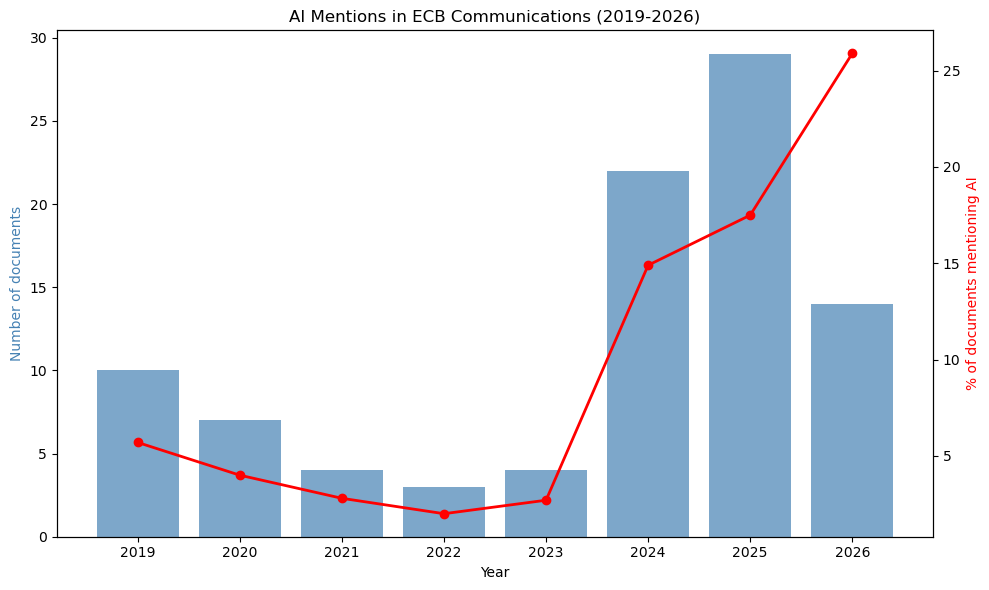

In [7]:
ai_by_year = df.groupby("year").agg(
    total_articles=("title", "count"),
    ai_articles=("has_ai_mention", "sum"),
).reset_index()

ai_by_year["ai_percentage"] = (
    ai_by_year["ai_articles"] / ai_by_year["total_articles"] * 100
).round(1)

print("AI Mentions by Year:")
print(ai_by_year.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(ai_by_year["year"], ai_by_year["ai_articles"],
        color="steelblue", alpha=0.7, label="Documents mentioning AI")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of documents", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(ai_by_year["year"], ai_by_year["ai_percentage"],
         color="red", marker="o", linewidth=2)
ax2.set_ylabel("% of documents mentioning AI", color="red")

plt.title("AI Mentions in ECB Communications (2019-2026)")
fig.tight_layout()
plt.savefig("data/chart_ai_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.2 Mentions by Document Type

This chart compares which document type mentions which topic more often. I expect speeches to have more AI and digital finance mentions because they are less formal and cover broader topics, while press releases focus more on monetary policy decisions.

Mentions by Document Type:
     doc_type  total  ai  digital  monetary
press_release    544   5       36       543
       speech    615  88      234       531


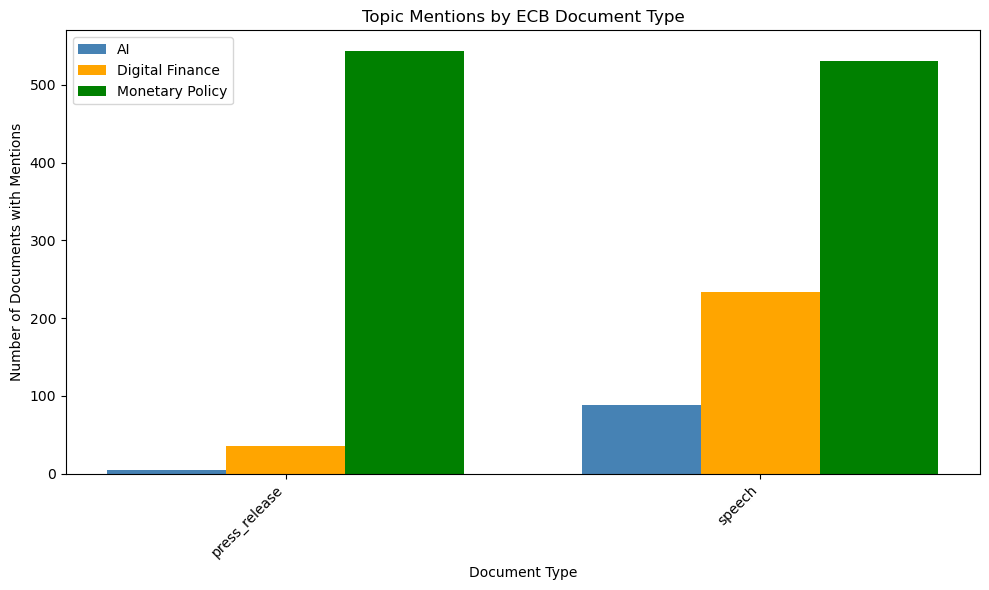

In [8]:
by_type = df.groupby("doc_type").agg(
    total=("title", "count"),
    ai=("has_ai_mention", "sum"),
    digital=("has_digital_mention", "sum"),
    monetary=("has_monetary_mention", "sum"),
).reset_index()

print("Mentions by Document Type:")
print(by_type.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(by_type))
width = 0.25

ax.bar([i - width for i in x], by_type["ai"],
       width, label="AI", color="steelblue")
ax.bar(x, by_type["digital"],
       width, label="Digital Finance", color="orange")
ax.bar([i + width for i in x], by_type["monetary"],
       width, label="Monetary Policy", color="green")

ax.set_xlabel("Document Type")
ax.set_ylabel("Number of Documents with Mentions")
ax.set_title("Topic Mentions by ECB Document Type")
ax.set_xticks(x)
ax.set_xticklabels(by_type["doc_type"], rotation=45, ha="right")
ax.legend()

fig.tight_layout()
plt.savefig("data/chart_by_doc_type.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.3 All Topics Over Time

This chart shows how all three topics evolve over time. Monetary policy should be consistently high (it is the ECB's core topic), while AI and digital finance should grow over the years.

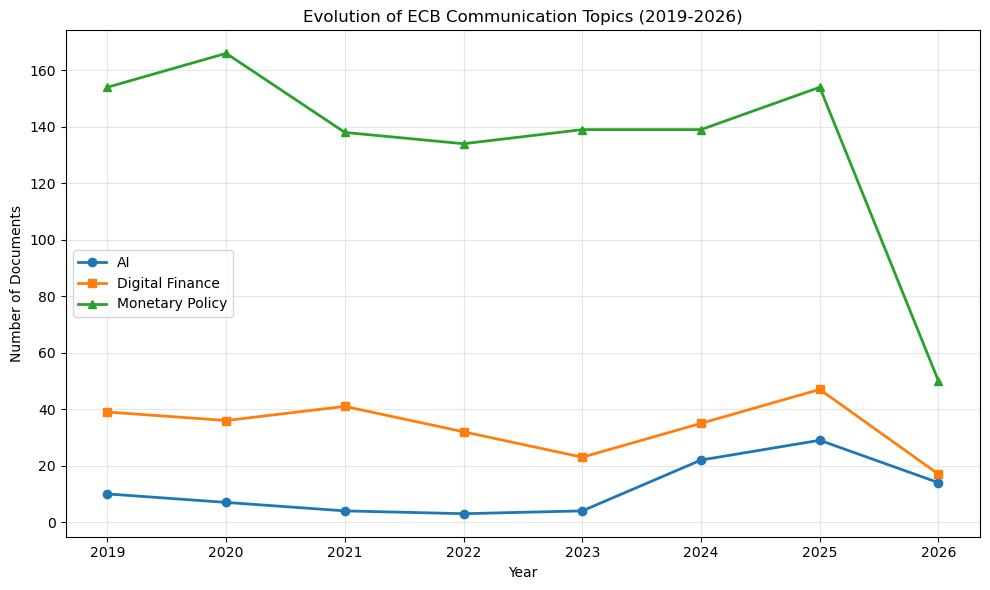

In [9]:
topics = df.groupby("year").agg(
    ai=("has_ai_mention", "sum"),
    digital=("has_digital_mention", "sum"),
    monetary=("has_monetary_mention", "sum"),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(topics["year"], topics["ai"],
        marker="o", label="AI", linewidth=2)
ax.plot(topics["year"], topics["digital"],
        marker="s", label="Digital Finance", linewidth=2)
ax.plot(topics["year"], topics["monetary"],
        marker="^", label="Monetary Policy", linewidth=2)

ax.set_xlabel("Year")
ax.set_ylabel("Number of Documents")
ax.set_title("Evolution of ECB Communication Topics (2019-2026)")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.savefig("data/chart_topics_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.4 Example AI-Mentioning Documents

In [10]:
ai_docs = df[df["has_ai_mention"] == True].sort_values("date_normalised")
print(f"Found {len(ai_docs)} documents mentioning AI topics\n")

print("First 15 AI-mentioning documents:")
for _, row in ai_docs.head(15).iterrows():
    print(f"  [{row['date_normalised']}] [{row['doc_type']}] {str(row['title'])[:80]}")

Found 93 documents mentioning AI topics

First 15 AI-mentioning documents:
  [2019-01-17] [speech] A supervisory perspective on 2019 and beyond
  [2019-02-26] [speech] Lending and payment systems in upheaval: the fintech challenge
  [2019-03-22] [speech] Remarks at the ‘Challenges in Understanding the Monetary Transmission Mechanism’
  [2019-05-10] [speech] Cyber resilience as a global public good
  [2019-05-16] [speech] The rise of services and the transmission of monetary policy
  [2019-07-04] [speech] Welcome address
  [2019-09-07] [speech] Growth and competitiveness in the euro area 
  [2019-11-28] [speech] Determinants of the real interest rate
  [2019-11-28] [speech] Economics as a profession: from science to practice
  [2019-12-18] [speech] Monetary policy: lifting the veil of effectiveness
  [2020-02-27] [speech] Monetary policy, low interest rates and low inflation
  [2020-05-22] [speech] International inflation co-movements
  [2020-06-10] [speech] The ECB’s policy in the COVI

## 9. Save Final Dataframe

In [11]:
# ============================================================
# SAVE THE FINAL STRUCTURED DATAFRAME
# This is the main output of the project.
# ============================================================

final_columns = [
    "doc_type",
    "title",
    "date_normalised",
    "year",
    "link",
    "has_ai_mention",
    "ai_mention_count",
    "has_digital_mention",
    "digital_mention_count",
    "has_monetary_mention",
    "monetary_mention_count",
]

for col in ["subtitle", "full_text", "description"]:
    if col in df.columns:
        final_columns.append(col)

df_final = df[final_columns].copy()
df_final = df_final.sort_values("date_normalised").reset_index(drop=True)

FINAL_OUTPUT = "data/ecb_final_dataset.csv"
df_final.to_csv(FINAL_OUTPUT, index=False, encoding="utf-8")

print(f"Final dataset saved to {FINAL_OUTPUT}")
print(f"Shape: {df_final.shape}")
print(f"\n=== FINAL SUMMARY ===")
print(f"Total documents:   {len(df_final)}")
print(f"  Speeches:        {len(df_final[df_final['doc_type']=='speech'])}")
print(f"  Press releases:  {len(df_final[df_final['doc_type']=='press_release'])}")
print(f"Date range:        {df_final['date_normalised'].min()} to {df_final['date_normalised'].max()}")
print(f"AI mentions:       {df_final['has_ai_mention'].sum()}")
print(f"Digital mentions:  {df_final['has_digital_mention'].sum()}")
print(f"Monetary mentions: {df_final['has_monetary_mention'].sum()}")

Final dataset saved to data/ecb_final_dataset.csv
Shape: (1159, 13)

=== FINAL SUMMARY ===
Total documents:   1159
  Speeches:        615
  Press releases:  544
Date range:        2019-01-07 to 2026-04-01
AI mentions:       93
Digital mentions:  270
Monetary mentions: 1074


In [ ]:
# Show the final dataframe
df_final.head(20)

## 10. Conclusion

This project successfully scraped the ECB website to collect speeches and press releases from 2019 to 2026. Here is a summary of what was done:

1. **Data discovery** — I found that the ECB's website uses a JSON dataset internally, which contains metadata for all their publications. This was better than RSS feeds (which only have the 15 most recent items) and better than archive pages (which are inconsistent).

2. **Data collection** — I used `requests` to download speech and press release metadata from the JSON dataset. I also used `BeautifulSoup` to validate the JSON data against the actual HTML pages.

3. **Full text extraction** — I used `Selenium` for speeches and `Scrapy` for press releases, so each tool handles a different content type.

4. **Analysis** — I used Python `re` (regex) to search for AI, digital finance, and monetary policy keywords. The word boundary `\b` anchor was important to avoid false matches (like matching 'said' when looking for 'AI').

5. **Final output** — A structured dataframe with all documents, enriched with topic classification columns.

The most interesting finding is that AI mentions in ECB communications have been increasing, especially after 2022 when generative AI became a major topic worldwide. Monetary policy mentions remain consistently high across all years, which makes sense because that is the ECB's main job. Digital finance mentions peaked around 2021-2022 when the digital euro project was being discussed heavily.

All scraping was done politely, respecting the ECB's `robots.txt` crawl delay of 5 seconds, and the project is for non-commercial academic purposes.